In [2]:
!pip install -q monai nibabel tqdm scikit-learn matplotlib pandas

from google.colab import drive
drive.mount("/content/drive")

import os, json, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset as TorchDataset, DataLoader

from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    ScaleIntensityRanged, CropForegroundd, SpatialPadd, RandSpatialCropd,
    RandFlipd, RandRotate90d, EnsureTyped
)

from monai.data import Dataset
from monai.networks.nets import UNet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)



Mounted at /content/drive


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Device: cuda


In [3]:
DRIVE_ROOT = "/content/drive/MyDrive/cs4782_final_project"
DATA_DRIVE = f"{DRIVE_ROOT}/data"
CKPT_DIR = f"{DRIVE_ROOT}/checkpoints"
RESULTS_DIR = f"{DRIVE_ROOT}/results"
import os

os.makedirs(DATA_DRIVE, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

In [4]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # These improve reproducibility, but can make training slightly slower.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [5]:
TASK_NAME = "Task04_Hippocampus"
TASK_TAR = f"{DATA_DRIVE}/{TASK_NAME}.tar"

LOCAL_DATA = "/content/data"
TASK_DIR = f"{LOCAL_DATA}/{TASK_NAME}"

!mkdir -p "$LOCAL_DATA"

if not os.path.exists(TASK_TAR):
    !wget -c https://msd-for-monai.s3-us-west-2.amazonaws.com/Task04_Hippocampus.tar -O "$TASK_TAR"
else:
    print("Dataset tar already exists in Drive.")

if not os.path.exists(TASK_DIR):
    !tar -xf "$TASK_TAR" -C "$LOCAL_DATA"
else:
    print("Dataset already extracted in this session.")

print("Using:", TASK_DIR)

Dataset tar already exists in Drive.
Using: /content/data/Task04_Hippocampus


In [6]:
dataset_json = os.path.join(TASK_DIR, "dataset.json")

with open(dataset_json, "r") as f:
    info = json.load(f)

all_files = []

for item in info["training"]:
    all_files.append({
        "image": os.path.join(TASK_DIR, item["image"]),
        "label": os.path.join(TASK_DIR, item["label"]),
    })

train_files, val_files = train_test_split(
    all_files,
    test_size=0.2,
    random_state=42
)

print("Total:", len(all_files))
print("Train:", len(train_files))
print("Val:", len(val_files))

Total: 260
Train: 208
Val: 52


In [7]:
ROI = (64, 64, 64)
PATCH = 24

ssl_transform = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Orientationd(keys=["image"], axcodes="RAS"),
    Spacingd(keys=["image"], pixdim=(1.5, 1.5, 1.5), mode=("bilinear")),
    ScaleIntensityRanged(keys=["image"], a_min=0, a_max=1, b_min=0, b_max=1, clip=True),
    CropForegroundd(keys=["image"], source_key="image"),
    SpatialPadd(keys=["image"], spatial_size=ROI),
    RandSpatialCropd(keys=["image"], roi_size=ROI, random_size=False),
    EnsureTyped(keys=["image"]),
])

train_seg_transform = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.5,1.5,1.5), mode=("bilinear","nearest")),
    ScaleIntensityRanged(keys=["image"], a_min=0, a_max=1, b_min=0, b_max=1, clip=True),
    CropForegroundd(keys=["image","label"], source_key="image"),
    SpatialPadd(keys=["image","label"], spatial_size=ROI),
    RandSpatialCropd(keys=["image","label"], roi_size=ROI, random_size=False),
    RandFlipd(keys=["image","label"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image","label"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image","label"], prob=0.5, spatial_axis=2),
    RandRotate90d(keys=["image","label"], prob=0.5, max_k=3),
    EnsureTyped(keys=["image","label"]),
])

val_seg_transform = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.5,1.5,1.5), mode=("bilinear","nearest")),
    ScaleIntensityRanged(keys=["image"], a_min=0, a_max=1, b_min=0, b_max=1, clip=True),
    CropForegroundd(keys=["image","label"], source_key="image"),
    SpatialPadd(keys=["image","label"], spatial_size=ROI),
    EnsureTyped(keys=["image","label"]),
])

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [8]:
class Encoder3D(nn.Module):
    def __init__(self, in_channels=1, feature_dim=256):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv3d(in_channels, 32, 3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(2),

            nn.Conv3d(32, 64, 3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(2),

            nn.Conv3d(64, 128, 3, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(2),

            nn.Conv3d(128, feature_dim, 3, padding=1),
            nn.BatchNorm3d(feature_dim),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool3d(1),
        )

    def forward(self, x):
        return self.conv(x).flatten(1)

In [9]:
ROTATIONS_10 = [
    ("none", 0),
    ("x", 1), ("x", 2), ("x", 3),
    ("y", 1), ("y", 2), ("y", 3),
    ("z", 1), ("z", 2), ("z", 3),
]

def rotate_3d(x, axis, k):
    if axis == "none":
        return x

    if axis == "x":
        dims = (2, 3)
    elif axis == "y":
        dims = (1, 3)
    elif axis == "z":
        dims = (1, 2)
    else:
        raise ValueError(axis)

    return torch.rot90(x, k=k, dims=dims)


def random_brightness_contrast(x):
    scale = torch.empty(1).uniform_(0.8, 1.2).item()
    shift = torch.empty(1).uniform_(-0.1, 0.1).item()
    return torch.clamp(x * scale + shift, 0.0, 1.0)

In [10]:
class RotationDataset(TorchDataset):
    def __init__(self, files):
        self.files = files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        x = ssl_transform({"image": self.files[idx]["image"]})["image"].float()

        y = random.randint(0, 9)
        axis, k = ROTATIONS_10[y]

        x = rotate_3d(x, axis, k)

        return x, torch.tensor(y).long()


class RotationModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder3D()
        self.head = nn.Linear(256, 10)

    def forward(self, x):
        return self.head(self.encoder(x))


class RPLDataset(TorchDataset):
    def __init__(self, files, patch=PATCH):
        self.files = files
        self.patch = patch

        self.positions = [
            (dz, dy, dx)
            for dz in [-1, 0, 1]
            for dy in [-1, 0, 1]
            for dx in [-1, 0, 1]
            if (dz, dy, dx) != (0, 0, 0)
        ]

    def __len__(self):
        return len(self.files)

    def crop_patch(self, x, z, y, w):
        p = self.patch
        return x[:, z:z+p, y:y+p, w:w+p]

    def __getitem__(self, idx):
        x = ssl_transform({"image": self.files[idx]["image"]})["image"].float()

        _, D, H, W = x.shape
        p = self.patch

        gap = random.randint(2, 5)
        step = p + gap

        cz = D // 2 - p // 2
        cy = H // 2 - p // 2
        cx = W // 2 - p // 2

        label = random.randint(0, 25)
        dz, dy, dx = self.positions[label]

        qz = max(0, min(D - p, cz + dz * step))
        qy = max(0, min(H - p, cy + dy * step))
        qx = max(0, min(W - p, cx + dx * step))

        center = self.crop_patch(x, cz, cy, cx)
        query = self.crop_patch(x, qz, qy, qx)

        return center, query, torch.tensor(label).long()


class RPLModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder3D()
        self.head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 26),
        )

    def forward(self, center, query):
        zc = self.encoder(center)
        zq = self.encoder(query)
        return self.head(torch.cat([zc, zq], dim=1))


def make_permutations(num_pieces=8, num_perms=64, seed=42):
    random.seed(seed)
    base = list(range(num_pieces))
    perms = set()

    while len(perms) < num_perms:
        p = base[:]
        random.shuffle(p)
        perms.add(tuple(p))

    return list(perms)


JIGSAW_PERMS = make_permutations()


class JigsawDataset(TorchDataset):
    def __init__(self, files):
        self.files = files
        self.perms = JIGSAW_PERMS

    def __len__(self):
        return len(self.files)

    def split_2x2x2(self, x):
        s = ROI[0] // 2
        pieces = []

        for z in [0, s]:
            for y in [0, s]:
                for w in [0, s]:
                    pieces.append(x[:, z:z+s, y:y+s, w:w+s])

        return pieces

    def reconstruct(self, pieces):
        idx = 0
        z_blocks = []

        for _ in range(2):
            y_blocks = []

            for _ in range(2):
                x_blocks = []

                for _ in range(2):
                    x_blocks.append(pieces[idx])
                    idx += 1

                y_blocks.append(torch.cat(x_blocks, dim=3))

            z_blocks.append(torch.cat(y_blocks, dim=2))

        return torch.cat(z_blocks, dim=1)

    def __getitem__(self, idx):
        x = ssl_transform({"image": self.files[idx]["image"]})["image"].float()

        pieces = self.split_2x2x2(x)

        label = random.randint(0, len(self.perms) - 1)
        perm = self.perms[label]

        shuffled = [pieces[i] for i in perm]
        x_jigsaw = self.reconstruct(shuffled)

        return x_jigsaw, torch.tensor(label).long()


class JigsawModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder3D()
        self.head = nn.Linear(256, len(JIGSAW_PERMS))

    def forward(self, x):
        return self.head(self.encoder(x))


class ExemplarDataset(TorchDataset):
    def __init__(self, files):
        self.files = files

    def __len__(self):
        return len(self.files)

    def augment(self, x):
        if random.random() < 0.5:
            x = torch.flip(x, dims=[random.choice([1, 2, 3])])

        if random.random() < 0.8:
            axis = random.choice(["x", "y", "z"])
            k = random.randint(1, 3)
            x = rotate_3d(x, axis, k)

        if random.random() < 0.8:
            x = random_brightness_contrast(x)

        return x

    def __getitem__(self, idx):
        anchor = ssl_transform({"image": self.files[idx]["image"]})["image"].float()
        positive = self.augment(anchor.clone())

        neg_idx = random.randint(0, len(self.files) - 1)

        while neg_idx == idx:
            neg_idx = random.randint(0, len(self.files) - 1)

        negative = ssl_transform({"image": self.files[neg_idx]["image"]})["image"].float()

        return anchor, positive, negative


class ExemplarModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder3D()

    def forward(self, x):
        return F.normalize(self.encoder(x), dim=1)


class CPCDataset(TorchDataset):
    def __init__(self, files, patch=PATCH):
        self.files = files
        self.patch = patch

    def __len__(self):
        return len(self.files)

    def crop(self, x, z, y, w):
        p = self.patch
        return x[:, z:z+p, y:y+p, w:w+p]

    def __getitem__(self, idx):
        x = ssl_transform({"image": self.files[idx]["image"]})["image"].float()

        _, D, H, W = x.shape
        p = self.patch

        # sample a 2x2x2 local cube of patches
        z = random.randint(0, max(0, D - 2*p - 1))
        y = random.randint(0, max(0, H - 2*p - 1))
        w = random.randint(0, max(0, W - 2*p - 1))

        patches = []

        for dz in [0, p]:
            for dy in [0, p]:
                for dx in [0, p]:
                    patches.append(self.crop(x, z+dz, y+dy, w+dx))

        # first 4 patches = context, last 4 = future targets
        context = torch.stack(patches[:4], dim=0)  # [4, C, p, p, p]
        future = torch.stack(patches[4:], dim=0)   # [4, C, p, p, p]

        return context, future

class CPCModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = Encoder3D()

        self.context_net = nn.GRU(
            input_size=256,
            hidden_size=256,
            batch_first=True
        )

        self.predictor = nn.Sequential(
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 256),
        )

    def forward(self, context, future):
        """
        context: [B, 4, C, p, p, p]
        future:  [B, 4, C, p, p, p]
        """

        B, Nc, C, D, H, W = context.shape
        _, Nf, _, _, _, _ = future.shape

        context = context.view(B * Nc, C, D, H, W)
        future = future.view(B * Nf, C, D, H, W)

        z_context = self.encoder(context).view(B, Nc, 256)
        z_future = self.encoder(future).view(B, Nf, 256)

        _, h = self.context_net(z_context)
        c = h[-1]  # [B, 256]

        pred = self.predictor(c)
        pred = F.normalize(pred, dim=1)

        # average future patches into one target representation
        target = z_future.mean(dim=1)
        target = F.normalize(target, dim=1)

        logits = pred @ target.T
        logits = logits / 0.07

        labels = torch.arange(B, device=logits.device)

        return logits, labels


class HybridRotationCPCDataset(TorchDataset):
    """
    One sample provides both:
      1. A rotated full 3D volume for rotation prediction
      2. Context/future patch groups for CPC
    This lets one encoder learn from both global orientation and local patch prediction.
    """
    def __init__(self, files, patch=PATCH):
        self.files = files
        self.patch = patch

    def __len__(self):
        return len(self.files)

    def crop(self, x, z, y, w):
        p = self.patch
        return x[:, z:z+p, y:y+p, w:w+p]

    def make_cpc_pair(self, x):
        _, D, H, W = x.shape
        p = self.patch

        z = random.randint(0, max(0, D - 2*p - 1))
        y = random.randint(0, max(0, H - 2*p - 1))
        w = random.randint(0, max(0, W - 2*p - 1))

        patches = []
        for dz in [0, p]:
            for dy in [0, p]:
                for dx in [0, p]:
                    patches.append(self.crop(x, z+dz, y+dy, w+dx))

        context = torch.stack(patches[:4], dim=0)
        future = torch.stack(patches[4:], dim=0)
        return context, future

    def __getitem__(self, idx):
        x = ssl_transform({"image": self.files[idx]["image"]})["image"].float()

        rot_label = random.randint(0, 9)
        axis, k = ROTATIONS_10[rot_label]
        x_rot = rotate_3d(x.clone(), axis, k)

        context, future = self.make_cpc_pair(x)

        return x_rot, torch.tensor(rot_label).long(), context, future


class HybridRotationCPCModel(nn.Module):
    """
    Beyond-paper extension: joint pretraining with two proxy losses.
    Rotation learns global orientation; CPC learns local predictive structure.
    """
    def __init__(self):
        super().__init__()
        self.encoder = Encoder3D()
        self.rotation_head = nn.Linear(256, 10)

        self.context_net = nn.GRU(
            input_size=256,
            hidden_size=256,
            batch_first=True,
        )
        self.cpc_predictor = nn.Sequential(
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 256),
        )

    def forward_rotation(self, x_rot):
        return self.rotation_head(self.encoder(x_rot))

    def forward_cpc(self, context, future):
        B, Nc, C, D, H, W = context.shape
        _, Nf, _, _, _, _ = future.shape

        context = context.view(B * Nc, C, D, H, W)
        future = future.view(B * Nf, C, D, H, W)

        z_context = self.encoder(context).view(B, Nc, 256)
        z_future = self.encoder(future).view(B, Nf, 256)

        _, h = self.context_net(z_context)
        c = h[-1]

        pred = F.normalize(self.cpc_predictor(c), dim=1)
        target = F.normalize(z_future.mean(dim=1), dim=1)

        logits = pred @ target.T
        logits = logits / 0.07
        labels = torch.arange(B, device=logits.device)

        return logits, labels

    def forward(self, x_rot, context, future):
        rot_logits = self.forward_rotation(x_rot)
        cpc_logits, cpc_labels = self.forward_cpc(context, future)
        return rot_logits, cpc_logits, cpc_labels


In [11]:
def train_rotation(files, epochs=1, batch_size=8):
    ds = RotationDataset(files)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=2)

    model = RotationModel().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-4)
    loss_fn = nn.CrossEntropyLoss()

    for ep in range(epochs):
        model.train()
        total_loss = 0

        for x, y in tqdm(dl, desc=f"Rotation {ep+1}/{epochs}"):
            x, y = x.to(device), y.to(device)

            opt.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            opt.step()

            total_loss += loss.item()

        print("Rotation loss:", total_loss / len(dl))

    path = f"{CKPT_DIR}/encoder_rotation.pth"
    torch.save(model.encoder.state_dict(), path)

    return path


def train_rpl(files, epochs=1, batch_size=8):
    ds = RPLDataset(files)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=2)

    model = RPLModel().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-4)
    loss_fn = nn.CrossEntropyLoss()

    for ep in range(epochs):
        model.train()
        total_loss = 0

        for c, q, y in tqdm(dl, desc=f"RPL {ep+1}/{epochs}"):
            c, q, y = c.to(device), q.to(device), y.to(device)

            opt.zero_grad()
            loss = loss_fn(model(c, q), y)
            loss.backward()
            opt.step()

            total_loss += loss.item()

        print("RPL loss:", total_loss / len(dl))

    path = f"{CKPT_DIR}/encoder_rpl.pth"
    torch.save(model.encoder.state_dict(), path)

    return path


def train_jigsaw(files, epochs=1, batch_size=8):
    ds = JigsawDataset(files)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=2)

    model = JigsawModel().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-4)
    loss_fn = nn.CrossEntropyLoss()

    for ep in range(epochs):
        model.train()
        total_loss = 0

        for x, y in tqdm(dl, desc=f"Jigsaw {ep+1}/{epochs}"):
            x, y = x.to(device), y.to(device)

            opt.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            opt.step()

            total_loss += loss.item()

        print("Jigsaw loss:", total_loss / len(dl))

    path = f"{CKPT_DIR}/encoder_jigsaw.pth"
    torch.save(model.encoder.state_dict(), path)

    return path


def train_exemplar(files, epochs=1, batch_size=8):
    ds = ExemplarDataset(files)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=2)

    model = ExemplarModel().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-4)
    loss_fn = nn.TripletMarginLoss(margin=1.0, p=2)

    for ep in range(epochs):
        model.train()
        total_loss = 0

        for a, p, n in tqdm(dl, desc=f"Exemplar {ep+1}/{epochs}"):
            a, p, n = a.to(device), p.to(device), n.to(device)

            opt.zero_grad()
            loss = loss_fn(model(a), model(p), model(n))
            loss.backward()
            opt.step()

            total_loss += loss.item()

        print("Exemplar loss:", total_loss / len(dl))

    path = f"{CKPT_DIR}/encoder_exemplar.pth"
    torch.save(model.encoder.state_dict(), path)

    return path


def train_cpc(files, epochs=1, batch_size=16):
    ds = CPCDataset(files)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)

    model = CPCModel().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-4)
    loss_fn = nn.CrossEntropyLoss()

    for ep in range(epochs):
        model.train()
        total_loss = 0

        for c, f in tqdm(dl, desc=f"CPC {ep+1}/{epochs}"):
            c, f = c.to(device), f.to(device)

            opt.zero_grad()

            logits, labels = model(c, f)
            loss = loss_fn(logits, labels)

            loss.backward()
            opt.step()

            total_loss += loss.item()

        print("CPC loss:", total_loss / len(dl))

    path = f"{CKPT_DIR}/encoder_cpc.pth"
    torch.save(model.encoder.state_dict(), path)

    return path


def train_hybrid_rotation_cpc(
    files,
    epochs=1,
    batch_size=8,
    lambda_rotation=1.0,
    lambda_cpc=1.0,
):
    """
    Beyond-paper experiment:
    Jointly pretrains one encoder with Rotation + CPC.
    """
    ds = HybridRotationCPCDataset(files)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)

    model = HybridRotationCPCModel().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-4)
    loss_fn = nn.CrossEntropyLoss()

    for ep in range(epochs):
        model.train()
        total_loss = 0
        total_rot_loss = 0
        total_cpc_loss = 0
        total_rot_correct = 0
        total_rot_seen = 0
        total_cpc_correct = 0
        total_cpc_seen = 0

        for x_rot, y_rot, context, future in tqdm(dl, desc=f"Hybrid Rot+CPC {ep+1}/{epochs}"):
            x_rot = x_rot.to(device)
            y_rot = y_rot.to(device)
            context = context.to(device)
            future = future.to(device)

            opt.zero_grad()

            rot_logits, cpc_logits, cpc_labels = model(x_rot, context, future)
            rot_loss = loss_fn(rot_logits, y_rot)
            cpc_loss = loss_fn(cpc_logits, cpc_labels)
            loss = lambda_rotation * rot_loss + lambda_cpc * cpc_loss

            loss.backward()
            opt.step()

            total_loss += loss.item()
            total_rot_loss += rot_loss.item()
            total_cpc_loss += cpc_loss.item()

            total_rot_correct += (rot_logits.argmax(1) == y_rot).sum().item()
            total_rot_seen += y_rot.numel()
            total_cpc_correct += (cpc_logits.argmax(1) == cpc_labels).sum().item()
            total_cpc_seen += cpc_labels.numel()

        print(
            "Hybrid loss:", total_loss / len(dl),
            "rot_loss:", total_rot_loss / len(dl),
            "cpc_loss:", total_cpc_loss / len(dl),
            "rot_acc:", total_rot_correct / max(1, total_rot_seen),
            "cpc_acc:", total_cpc_correct / max(1, total_cpc_seen),
        )

    path = f"{CKPT_DIR}/encoder_hybrid_rotation_cpc.pth"
    torch.save(model.encoder.state_dict(), path)

    return path


In [12]:
PRETRAIN_EPOCHS = 20
FORCE_RETRAIN = False
FORCE_RETRAIN_HYBRID = False  # set True when changing HybridRotationCPCModel/Dataset

encoder_paths = {
    "rotation": f"{CKPT_DIR}/encoder_rotation.pth",
    "rpl": f"{CKPT_DIR}/encoder_rpl.pth",
    "jigsaw": f"{CKPT_DIR}/encoder_jigsaw.pth",
    "exemplar": f"{CKPT_DIR}/encoder_exemplar.pth",
    "cpc": f"{CKPT_DIR}/encoder_cpc.pth",
    "hybrid_rot_cpc": f"{CKPT_DIR}/encoder_hybrid_rotation_cpc.pth",
}

if FORCE_RETRAIN:
    for path in encoder_paths.values():
        if os.path.exists(path):
            os.remove(path)
            print("Deleted:", path)
elif FORCE_RETRAIN_HYBRID and os.path.exists(encoder_paths["hybrid_rot_cpc"]):
    os.remove(encoder_paths["hybrid_rot_cpc"])
    print("Deleted:", encoder_paths["hybrid_rot_cpc"])

if not os.path.exists(encoder_paths["rotation"]):
    encoder_paths["rotation"] = train_rotation(train_files, epochs=PRETRAIN_EPOCHS)

if not os.path.exists(encoder_paths["rpl"]):
    encoder_paths["rpl"] = train_rpl(train_files, epochs=PRETRAIN_EPOCHS)

if not os.path.exists(encoder_paths["jigsaw"]):
    encoder_paths["jigsaw"] = train_jigsaw(train_files, epochs=PRETRAIN_EPOCHS)

if not os.path.exists(encoder_paths["exemplar"]):
    encoder_paths["exemplar"] = train_exemplar(train_files, epochs=PRETRAIN_EPOCHS)

if not os.path.exists(encoder_paths["cpc"]):
    encoder_paths["cpc"] = train_cpc(train_files, epochs=PRETRAIN_EPOCHS)

if not os.path.exists(encoder_paths["hybrid_rot_cpc"]):
    encoder_paths["hybrid_rot_cpc"] = train_hybrid_rotation_cpc(
        train_files,
        epochs=PRETRAIN_EPOCHS,
        batch_size=8,
        lambda_rotation=1.0,
        lambda_cpc=1.0,
    )

encoder_paths


Rotation 1/20: 100%|██████████| 26/26 [00:01<00:00, 13.94it/s]


Rotation loss: 2.200653617198651


Rotation 2/20: 100%|██████████| 26/26 [00:00<00:00, 42.04it/s]


Rotation loss: 1.8939546346664429


Rotation 3/20: 100%|██████████| 26/26 [00:00<00:00, 41.85it/s]


...

Hybrid Rot+CPC 19/20: 100%|██████████| 26/26 [00:00<00:00, 33.07it/s]


Hybrid loss: 1.6152743330368629 rot_loss: 1.5079223834551299 cpc_loss: 0.10735195688903332 rot_acc: 0.34134615384615385 cpc_acc: 0.9855769230769231


Hybrid Rot+CPC 20/20: 100%|██████████| 26/26 [00:00<00:00, 33.23it/s]

Hybrid loss: 1.7085307469734778 rot_loss: 1.6091679563889136 cpc_loss: 0.09936279774858402 rot_acc: 0.3076923076923077 cpc_acc: 0.9855769230769231


{'rotation': '/content/drive/MyDrive/cs4782_final_project/checkpoints/encoder_rotation.pth',
 'rpl': '/content/drive/MyDrive/cs4782_final_project/checkpoints/encoder_rpl.pth',
 'jigsaw': '/content/drive/MyDrive/cs4782_final_project/checkpoints/encoder_jigsaw.pth',
 'exemplar': '/content/drive/MyDrive/cs4782_final_project/checkpoints/encoder_exemplar.pth',
 'cpc': '/content/drive/MyDrive/cs4782_final_project/checkpoints/encoder_cpc.pth',
 'hybrid_rot_cpc': '/content/drive/MyDrive/cs4782_final_project/checkpoints/encoder_hybrid_rotation_cpc.pth'}

In [13]:
def build_unet():
    return UNet(
        spatial_dims=3,
        in_channels=1,
        out_channels=3,
        channels=(32, 64, 128, 256),
        strides=(2, 2, 2),
        num_res_units=2,
    ).to(device)


def load_encoder_into_unet(unet, encoder_path):
    encoder_state = torch.load(encoder_path, map_location=device)
    unet_state = unet.state_dict()

    matched = {}
    used = set()

    for ek, ev in encoder_state.items():
        for uk, uv in unet_state.items():
            if uk not in used and ev.shape == uv.shape:
                matched[uk] = ev
                used.add(uk)
                break

    unet_state.update(matched)
    unet.load_state_dict(unet_state)

    print("Matched pretrained layers:", len(matched))

    return unet


def make_labeled_subset(files, fraction, seed):
    random.seed(seed)
    n = max(1, int(len(files) * fraction))
    return random.sample(files, n)


def make_loaders_for_fraction(fraction, seed, batch_size=2):
    subset_train_files = make_labeled_subset(train_files, fraction, seed)

    subset_train_ds = Dataset(subset_train_files, transform=train_seg_transform)
    val_ds = Dataset(val_files, transform=val_seg_transform)

    subset_train_loader = DataLoader(
        subset_train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=1,
        shuffle=False,
        num_workers=2,
    )

    return subset_train_loader, val_loader, len(subset_train_files)


def set_unet_encoder_freeze(model, freeze=True, fraction_to_freeze=0.5):
    """
    Practical freezing helper for MONAI U-Net.
    MONAI's nested module names are not as clean as a custom encoder/decoder split,
    so this freezes the first fraction of parameters by order, which roughly corresponds
    to earlier encoder/downsampling layers.
    """
    named_params = list(model.named_parameters())
    cutoff = int(len(named_params) * fraction_to_freeze)

    for i, (name, param) in enumerate(named_params):
        if i < cutoff:
            param.requires_grad = not freeze

    action = "Frozen" if freeze else "Unfrozen"
    print(f"{action} first {cutoff}/{len(named_params)} parameter tensors.")


def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True
    print("Unfrozen all model parameters.")


In [14]:
def finetune_model_with_loaders(
    method_name,
    train_loader,
    val_loader,
    encoder_path=None,
    epochs=5,
    fraction=1.0,
    freeze_pretrained_epochs=0,
):
    model = build_unet()

    using_pretrained = encoder_path is not None

    if using_pretrained:
        model = load_encoder_into_unet(model, encoder_path)

    # Beyond-paper option: freeze pretrained encoder-like layers early, then unfreeze.
    # This can help test whether SSL features are already useful in low-data settings.
    if using_pretrained and freeze_pretrained_epochs > 0:
        set_unet_encoder_freeze(model, freeze=True, fraction_to_freeze=0.5)

    loss_fn = DiceCELoss(to_onehot_y=True, softmax=True)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-4,
    )
    dice_metric = DiceMetric(include_background=False, reduction="mean")

    best_dice = 0

    for epoch in range(epochs):
        # Unfreeze after the warm-up freeze period.
        if using_pretrained and freeze_pretrained_epochs > 0 and epoch == freeze_pretrained_epochs:
            unfreeze_all(model)
            optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

        model.train()
        total_loss = 0

        for batch in tqdm(
            train_loader,
            desc=f"{method_name} | {int(fraction * 100)}% | epoch {epoch+1}/{epochs}",
        ):
            images = batch["image"].to(device)
            labels = batch["label"].to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = loss_fn(outputs, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        model.eval()
        dice_metric.reset()

        with torch.no_grad():
            for batch in val_loader:
                images = batch["image"].to(device)
                labels = batch["label"].to(device)

                outputs = sliding_window_inference(images, ROI, 1, model)
                preds = torch.argmax(outputs, dim=1, keepdim=True)

                dice_metric(y_pred=preds, y=labels)

        val_dice = dice_metric.aggregate().item()
        avg_loss = total_loss / len(train_loader)

        print(
            f"{method_name} | {int(fraction * 100)}% | "
            f"epoch {epoch+1}: loss={avg_loss:.4f}, dice={val_dice:.4f}"
        )

        if val_dice > best_dice:
            best_dice = val_dice
            save_name = f"{method_name}_{int(fraction * 100)}percent_best_unet.pth"
            torch.save(model.state_dict(), f"{CKPT_DIR}/{save_name}")

    return best_dice


In [15]:
FRACTIONS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
FINETUNE_EPOCHS = 40
SEEDS = [0, 1, 2]
FREEZE_PRETRAINED_EPOCHS = 5  # set to 0 to disable encoder-freezing experiment

all_results = []

methods = {
    "scratch": None,
    "rotation": encoder_paths["rotation"],
    "rpl": encoder_paths["rpl"],
    "jigsaw": encoder_paths["jigsaw"],
    "exemplar": encoder_paths["exemplar"],
    "cpc": encoder_paths["cpc"],
    "hybrid_rot_cpc": encoder_paths["hybrid_rot_cpc"],
}

for seed in SEEDS:
    set_seed(seed)

    for fraction in FRACTIONS:
        print("=" * 80)
        print(f"Seed {seed} | {int(fraction * 100)}% labeled data")
        print("=" * 80)

        train_loader_frac, val_loader_frac, n_train = make_loaders_for_fraction(
            fraction,
            seed=seed
        )

        for method_name, encoder_path in methods.items():
            print(f"\n--- {method_name.upper()} ---")

            freeze_epochs = 0 if method_name == "scratch" else FREEZE_PRETRAINED_EPOCHS

            best_dice = finetune_model_with_loaders(
                method_name=method_name,
                train_loader=train_loader_frac,
                val_loader=val_loader_frac,
                encoder_path=encoder_path,
                epochs=FINETUNE_EPOCHS,
                fraction=fraction,
                freeze_pretrained_epochs=freeze_epochs,
            )

            all_results.append({
                "seed": seed,
                "method": method_name,
                "labeled_fraction": fraction,
                "labeled_percent": int(fraction * 100),
                "num_train_samples": n_train,
                "freeze_pretrained_epochs": freeze_epochs,
                "best_val_dice": best_dice,
            })


Output hidden; open in https://colab.research.google.com to view.

In [16]:
results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    ["labeled_percent", "best_val_dice"],
    ascending=[False, False],
)

display(results_df)

csv_path = f"{RESULTS_DIR}/all_proxy_task_results.csv"
results_df.to_csv(csv_path, index=False)

print("Saved to:", csv_path)

,seed,method,labeled_fraction,labeled_percent,num_train_samples,freeze_pretrained_epochs,best_val_dice
209,2,hybrid_rot_cpc,1.0,100,208,5,0.401210
136,1,jigsaw,1.0,100,208,5,0.400063
205,2,rpl,1.0,100,208,5,0.394840
64,0,rotation,1.0,100,208,5,0.367240
138,1,cpc,1.0,100,208,5,0.362348
...,...,...,...,...,...,...,...
74,1,exemplar,0.1,10,20,5,0.069561
0,0,scratch,0.1,10,20,0,0.061416
75,1,cpc,0.1,10,20,5,0.058269
3,0,jigsaw,0.1,10,20,5,0.056962


Saved to: /content/drive/MyDrive/cs4782_final_project/results/all_proxy_task_results.csv


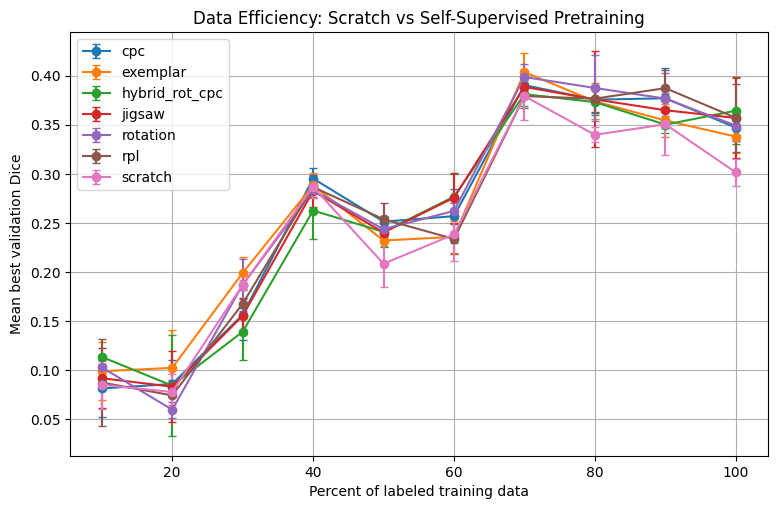

Plot saved to: /content/drive/MyDrive/cs4782_final_project/results/data_efficiency_plot_mean_std_errorbars.png


In [ ]:
import matplotlib.pyplot as plt

summary_df = (
    results_df
    .groupby(["method", "labeled_percent"], as_index=False)
    .agg(
        mean_dice=("best_val_dice", "mean"),
        std_dice=("best_val_dice", "std")
    )
)

plt.figure(figsize=(9, 5.5))

# for method in summary_df["method"].unique():
#     sub = summary_df[summary_df["method"] == method].sort_values("labeled_percent")

#     plt.errorbar(
#         sub["labeled_percent"],
#         sub["mean_dice"],
#         yerr=sub["std_dice"],
#         marker="o",
#         capsize=3,
#         label=method,
#     )

plt.xlabel("Percent of labeled training data")
plt.ylabel("Mean best validation Dice")
plt.title("Data Efficiency: Scratch vs Self-Supervised Pretraining")
plt.legend()
plt.grid(True)

plot_path = f"{RESULTS_DIR}/data_efficiency_plot_mean_std_errorbars.png"
plt.savefig(plot_path, dpi=200, bbox_inches="tight")

plt.show()
print("Plot saved to:", plot_path)
